In [1]:
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams.update({'font.size': 14})
from scipy.ndimage import gaussian_filter
from matplotlib.colors import LogNorm
import matplotlib.ticker as ticker
from matplotlib.colors import Normalize
import sys
import os
sys.path.append(os.path.abspath('..'))
from scripts.analysis_utils import get_density2d, get_density1d, \
    make_levels, add_colorbar, add_crosshair, get_sensitivity

In [2]:
data = np.loadtxt('synthetic_map_with_tsky.txt')
f = data[:, 1]
DM = data[:, 2]
S = data[:, 3]
FWHM = data[:, 4]
sigma = data[:, 5]
nharm = data[:, 6]

f_idx = 1
DM_idx = 2
S_idx = 3
FWHM_idx = 4
sigma_idx = 5
nharm_idx = 6

In [3]:
f_bins = np.logspace(np.log10(min(f)), np.log10(max(f)), 1001)
DM_bins = np.arange(min(DM), 700, 1.)
S_bins = np.logspace(np.log10(min(S)), np.log10(max(S)), 101)
FWHM_bins = np.logspace(np.log10(min(FWHM)), -0.95, 101)

Start with 1D analysis:

In [4]:
f_bins= np.logspace(-3, 2.7, 101)
f_inj_p_smooth, f_ret_p, f_ret_p_smooth = get_sensitivity(
    full_data = data, 
    col = f_idx, 
    bins = f_bins, 
    gauss_dev = 5,
    predicted = True,
)

DM_bins = np.linspace(0, 400, 50)
DM_inj_p_smooth, DM_ret_p, DM_ret_p_smooth = get_sensitivity(
    full_data = data,
    col = DM_idx,
    bins = DM_bins,
    gauss_dev = 12,
    predicted = True,
)

S_bins = np.logspace(-2, 1, 101)
S_inj_p_smooth, S_ret_p, S_ret_p_smooth = get_sensitivity(
    full_data = data,
    col = S_idx,
    bins = S_bins,
    gauss_dev = 5,
    predicted = True,
)

FWHM_bins = np.logspace(np.log10(min(FWHM)), -0.95, 101)
FWHM_inj_p_smooth, FWHM_ret_p, FWHM_ret_p_smooth = get_sensitivity(
    full_data = data,
    col = FWHM_idx,
    bins = FWHM_bins,
    gauss_dev = 10,
    predicted = True,
)


/data1/people/rsquillace/Transmissivity/scripts/analysis_utils.py:16: RuntimeWarning: invalid value encountered in divide
  arr_ret_p = arr_retrieved / arr_injected


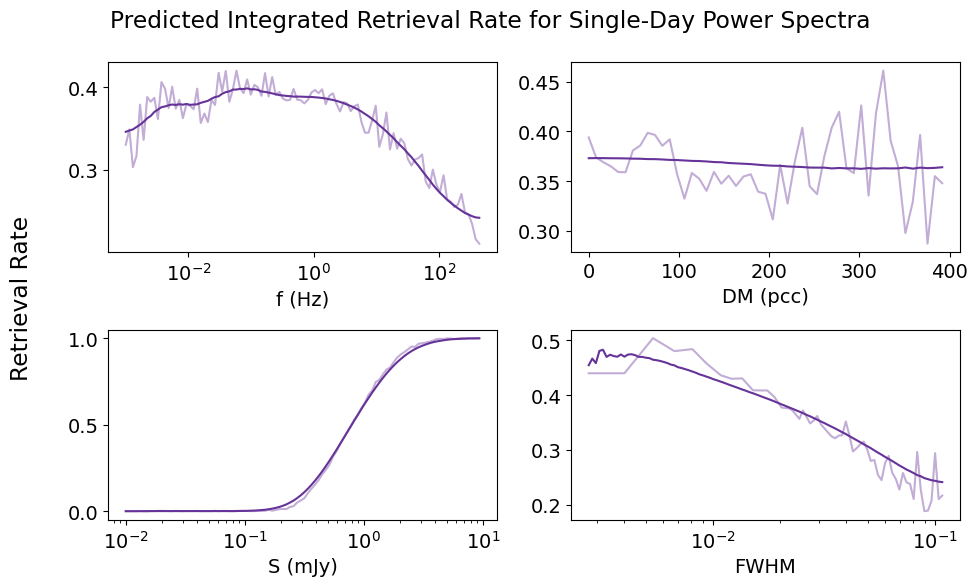

In [8]:
fig, ax = plt.subplots(2, 2, figsize=(10, 6))
ax = ax.flatten()
ax[0].plot(f_bins[:-1], f_ret_p_smooth, color='rebeccapurple', label='First')
ax[0].plot(f_bins[:-1], f_ret_p, alpha=0.4, color='rebeccapurple')
ax[0].set_xscale('log')
ax[0].set_xlabel('f (Hz)')

ax[1].plot(DM_bins[:-1], DM_ret_p_smooth, color='rebeccapurple', label='First')
ax[1].plot(DM_bins[:-1], DM_ret_p, alpha=0.4, color='rebeccapurple')
#ax[1].plot(DM_bins[:-1], DM_ret_p_smooth_all, color='hotpink', label='All')
#ax[1].plot(DM_bins[:-1], DM_ret_p_all, alpha=0.4, color='hotpink')
ax[1].set_xlabel('DM (pcc)')

ax[2].plot(S_bins[:-1], S_ret_p_smooth, color='rebeccapurple', label='First')
ax[2].plot(S_bins[:-1], S_ret_p, alpha=0.4, color='rebeccapurple')
ax[2].set_xscale('log')
ax[2].set_xlabel('S (mJy)')

ax[3].plot(FWHM_bins[:-1], FWHM_ret_p_smooth, color='rebeccapurple', label='First')
ax[3].plot(FWHM_bins[:-1], FWHM_ret_p, alpha=0.4, color='rebeccapurple')
ax[3].set_xscale('log')
ax[3].set_xlabel('FWHM')


fig.suptitle('Predicted Integrated Retrieval Rate for Single-Day Power Spectra')
fig.supylabel('Retrieval Rate')
#handles, labels = ax[0].get_legend_handles_labels()
#fig.legend(handles, labels, title='Harmonics Counted', loc='upper right',
#           bbox_to_anchor=(1.0, 1.0), bbox_transform=fig.transFigure)
plt.tight_layout()